In [ ]:
import numpy as np
import h5py
import math
import os
import pathlib
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline
import torch
import random
import torch.nn as nn
import sklearn
import collections
from sklearn.model_selection import train_test_split
import torch.nn.functional as F
import json
from torch.optim import Adam
import pylab
from scipy.optimize import curve_fit
from google.colab import drive
drive.mount('/content/gdrive')
import sys
sys.path.insert(0,'/content/gdrive/MyDrive/Penn/Colab/Data/')
from functions import load_model, save_model, Dataset, mse_loss
from sklearn.metrics import roc_curve, auc

Mounted at /content/gdrive


## Load Data

In [ ]:
# Load Background data, which will be used for training
filename = 'BKG_dataset.h5'
with h5py.File('/content/gdrive/MyDrive/Penn/Colab/Data/BKG_dataset.h5', 'r') as file:
    X_train = np.array(file['X_train'])
    X_test = np.array(file['X_test'])
    X_val = np.array(file['X_val'])

print(X_train.shape)

(640000, 57)


In [ ]:
BATCH_SIZE = 1024

In [ ]:
# Initialize datasets
train_dataset = Dataset(X=X_train, y=X_train)
test_dataset = Dataset(X=X_test, y=X_test)
val_dataset = Dataset(X=X_val, y=X_val)

In [ ]:
# Initialize dataloaders
train_loader = train_dataset.create_dataloader(batch_size=BATCH_SIZE, shuffle=True)
test_loader = test_dataset.create_dataloader(batch_size=BATCH_SIZE, shuffle=False)
val_loader = val_dataset.create_dataloader(batch_size=BATCH_SIZE, shuffle=False)
batch_X, batch_y = next(iter(train_loader))
print ("Sample batch:\n"
    f"  X: {list(batch_X.size())}\n"
    f"  y: {list(batch_y.size())}\n")

Sample batch:
  X: [1024, 57]
  y: [1024, 57]



/content/gdrive/MyDrive/Penn/Colab/Data/functions.py:32: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X = [torch.tensor(sample[0]).float() for sample in batch]
/content/gdrive/MyDrive/Penn/Colab/Data/functions.py:33: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y = [torch.tensor(sample[1]).float() for sample in batch]


## DNN and Trainer Classes

In [ ]:
class DNN_VAE(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        """input_dim: dimension of the input data.
        latent_dim: dimension of the latent space. Should be smaller than all of the other layers.
        num_nodes: two element array containing the number of nodes in the two hidden layers."""
        super(DNN_VAE, self).__init__()

        # Encoder layers
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc_mean = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

        # Decoder layers
        self.fc2 = nn.Linear(latent_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, input_dim)

    def forward(self, x_in):
        """Forward through the autoencoder with relu activation."""

        # Encoder
        h = F.relu(self.fc1(x_in))
        mean = self.fc_mean(h)
        logvar = self.fc_logvar(h)

        # reparameterize
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        z = mean + eps*std

        # Decoder
        h = F.relu(self.fc2(z))
        z = self.fc3(h)
        return z, mean, logvar

    def loss_function(self, x, y, mu, logvar, beta=0.4):
        """Compute the VAE loss. Beta was calculated to be roughly 0.4 for equal
        contribution of mse and kl loss terms."""
        # Reconstruction loss (MSE)
        mask = (y != 0)
        _y = mask * y
        _x = mask*x
        recon_loss = F.mse_loss(_x, _y, reduction='mean')

        # KL divergence loss
        kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())

        # Total loss
        loss = (1 - beta)*recon_loss + beta*kl_loss
        return loss

In [ ]:
# Define a class which will handle training and testing the model
class Trainer(object):
    def __init__(self, model, num_batches_avg, loss_fn=None, optimizer=None, scheduler=None):
        """num_batches_avg: Number of batches to calculate the average loss over.
        example: if there are 625 batches, we might want to use 25, to calculate
        average loss over 25 batches."""

        #Set params
        self.model = model
        self.loss_fn = loss_fn
        self.optimizer = optimizer
        self.scheduler = scheduler
        self.num_batches_avg = num_batches_avg

    def train_step(self, dataloader):
        """Train for one epoch.

        returns: average loss over most recent {num_batches_avg} batches, loss over most recent batch
        """

        self.model.train()
        current_loss = 0.0 # Average loss of most recent batch
        avg_loss = 0.0 # Average loss over a certain number of batches
        running_loss = 0.0

        # Iterate over batches in dataloader
        for i, batch in enumerate(dataloader):

            # Pass a single batch through the model and update the weights
            inputs, targets = batch
            self.optimizer.zero_grad()
            outputs, mu, logvar = self.model(inputs)
            loss = self.loss_fn(outputs, targets, mu, logvar)
            loss.backward()
            #torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
            self.optimizer.step()

            # Update loss metrics
            running_loss += loss.item()
            current_loss = loss.item()

            # Calculate the average loss
            if i % self.num_batches_avg == self.num_batches_avg - 1:
                avg_loss = running_loss / self.num_batches_avg
                running_loss = 0.0

        return avg_loss, current_loss

    def eval_step(self, dataloader):
        """validation or test step over one epoch."""

        self.model.eval()
        current_loss = 0.0 # Average loss of most recent batch
        avg_loss = 0.0 # Average loss over a certain number of batches
        running_loss = 0.0
        y_trues, model_outputs = [], []

        # Iterate over val batches
        with torch.no_grad():
            for i, batch in enumerate(dataloader):

                # Pass a single batch through the model
                inputs, y_true = batch
                outputs, mu, logvar = self.model(inputs)
                loss = self.loss_fn(outputs, y_true, mu, logvar)

                # Update loss metrics
                running_loss += loss.item()
                current_loss = loss.item()

                # Calculate the average loss
                if i % self.num_batches_avg == self.num_batches_avg - 1:
                    avg_loss = running_loss / self.num_batches_avg
                    running_loss = 0.0

                # Store outputs
                y_trues.extend(y_true)
                model_outputs.extend(outputs)
        return avg_loss, current_loss, np.vstack(y_trues), np.vstack(model_outputs)

    def predict_step(self, dataloader):
        """Prediction step."""
        self.model.eval()
        model_outputs = []

        # Iterate over batches
        with torch.no_grad():
            for i, batch in enumerate(dataloader):

                # Pass a single batch through the model
                inputs, targets = batch
                outputs, mu , logvar = self.model(inputs)

                # Store outputs
                model_outputs.extend(outputs)

        return np.vstack(model_outputs), np.vstack(mu), np.vstack(logvar)

    def train(self, num_epochs, patience, train_dataloader, val_dataloader):
        """Train the neural net."""

        best_val_loss = np.inf
        patience_counter=patience

        # Loop over epochs
        for epoch in range(num_epochs):

            # Steps
            avg_train_loss, last_train_loss = self.train_step(dataloader=train_dataloader)
            avg_val_loss, last_val_loss, _, _ = self.eval_step(dataloader=val_dataloader)
            self.scheduler.step(avg_val_loss)

            # Early stopping
            if avg_val_loss < best_val_loss:
                best_val_loss = avg_val_loss
                best_model = self.model
                patience_counter = patience # reset patience
            else:
                patience_counter -= 1
            if not patience_counter: # 0
                print("Stoping Early!")
                break

            # Logging
            print(f'Epoch: {epoch+1} | '
            f'average train loss over most recent {self.num_batches_avg} batches: {avg_train_loss},'
            f'average val loss over most recent {self.num_batches_avg} batches: {avg_val_loss},'
            #f'learning rate: {self.optimizer.param_groups[0]['lr']:.2E},'
            f'patience counter: {patience_counter}')

        return best_model

## Initialize Model and Train

In [ ]:
# Define consts
LEARNING_RATE = 1e-3
PATIENCE = 7
NUM_EPOCHS = 33

In [ ]:
# Initialize model
INPUT_DIM = X_train.shape[1]
HIDDEN_DIM = 16
LATENT_DIM = 3
dense_VAE = DNN_VAE(input_dim=INPUT_DIM, hidden_dim=HIDDEN_DIM, latent_dim=LATENT_DIM)
print(dense_VAE.named_parameters)

<bound method Module.named_parameters of DNN_VAE(
  (fc1): Linear(in_features=57, out_features=16, bias=True)
  (fc_mean): Linear(in_features=16, out_features=3, bias=True)
  (fc_logvar): Linear(in_features=16, out_features=3, bias=True)
  (fc2): Linear(in_features=3, out_features=16, bias=True)
  (fc3): Linear(in_features=16, out_features=57, bias=True)
)>


In [ ]:
# Calculate the appropriate beta value for loss function
# (We want the mse and kl loss terms to be roughly equal contributions)

outputs, mu, logvar = dense_VAE(batch_X)
mask = (batch_X != 0)
_mse_loss = F.mse_loss(mask*outputs, mask*batch_X, reduction='mean')
kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
beta = _mse_loss / (kl_loss + _mse_loss)
print(f'mse loss: {_mse_loss}')
print(f'kl loss: {kl_loss}')
print(f'beta: {beta}')

mse loss: 88.34005737304688
kl loss: 61.052310943603516
beta: 0.5913291573524475


In [ ]:
# Initialize the loss function, optimizer and lr scheduler, trainer
def loss_fn(x, y, mu, logvar):
    return dense_VAE.loss_function(x, y, mu, logvar)
optimizer = Adam(params=dense_VAE.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.2, patience=5, verbose=True)
trainer = Trainer(model=dense_VAE, num_batches_avg=25,
                  loss_fn=loss_fn, optimizer=optimizer, scheduler=scheduler)

/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [ ]:
# # Train
# best_model = trainer.train(
#     num_epochs=NUM_EPOCHS, patience=PATIENCE,
#     train_dataloader=train_loader, val_dataloader=val_loader)

In [ ]:
# # Save model
# save_model(best_model, 'DNN_VAE_4')

In [ ]:
# Load model
dense_VAE = DNN_VAE(input_dim=INPUT_DIM, hidden_dim=HIDDEN_DIM, latent_dim=LATENT_DIM)
dense_VAE = load_model(dense_VAE, 'DNN_VAE_4')
trainer = Trainer(model=dense_VAE, num_batches_avg=25,
                  loss_fn=loss_fn, optimizer=optimizer, scheduler=scheduler)

/content/gdrive/MyDrive/Penn/Colab/Data/functions.py:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('/content/gdrive/MyDrive/Penn/Colab/T

## Prediction

In [ ]:
# Calculate the appropriate beta value for loss function
# (We want the mse and kl loss terms to be roughly equal contributions)

outputs, mu, logvar = dense_VAE(batch_X)
mask = (batch_X != 0)
_mse_loss = F.mse_loss(mask*outputs, mask*batch_X, reduction='mean')
kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
beta = _mse_loss / (kl_loss + _mse_loss)
print(f'mse loss: {_mse_loss}')
print(f'kl loss: {kl_loss}')
print(f'beta: {beta}')

mse loss: 1.1601932048797607
kl loss: 1.6752151250839233
beta: 0.40918031334877014


In [ ]:
#bkg_prediction, bkg_mu, bkg_logvar = trainer.predict_step(dataloader=test_loader)
train_prediction, train_mu, train_logvar = dense_VAE(torch.tensor(X_train, requires_grad=False).float())
val_prediction, val_mu, val_logvar = dense_VAE(torch.tensor(X_val, requires_grad=False).float())
bkg_prediction, bkg_mu, bkg_logvar = dense_VAE(torch.tensor(X_test, requires_grad=False).float())

train_prediction = train_prediction.detach().numpy()
val_prediction = val_prediction.detach().numpy()
bkg_prediction = bkg_prediction.detach().numpy()

In [ ]:
# add correct signal labels
signal_labels = ['Ato4l', 'hChToTauNu', 'hToTauTau', 'leptoquark']

In [ ]:
# add correct path to signal files
drive_path = '/content/gdrive/MyDrive/Penn/Colab/Data/'
signals_file = [drive_path+label+'_dataset.h5' for label in signal_labels]
print(signals_file)

['/content/gdrive/MyDrive/Penn/Colab/Data/Ato4l_dataset.h5', '/content/gdrive/MyDrive/Penn/Colab/Data/hChToTauNu_dataset.h5', '/content/gdrive/MyDrive/Penn/Colab/Data/hToTauTau_dataset.h5', '/content/gdrive/MyDrive/Penn/Colab/Data/leptoquark_dataset.h5']


In [ ]:
# read signal data
signal_data = []
for i, label in enumerate(signal_labels):
    with h5py.File(signals_file[i], 'r') as file:
        test_data = np.array(file[label])
    signal_data.append(test_data)

#print(np.array(signal_data).shape)

In [ ]:
signal_results = []
sig_mu = []
sig_logvar = []

for i, label in enumerate(signal_labels):
    signal_prediction, mu, logvar = dense_VAE(torch.tensor(signal_data[i], requires_grad=False).float())
    signal_results.append([label, signal_data[i], signal_prediction]) # save [label, true, prediction] for signal
    sig_mu.append(mu)
    sig_logvar.append(logvar)

## MSE KL Score

In [ ]:
def mse_loss_masked(y, x):
    mask = (y != 0)
    _x = mask * x
    _y = mask * y
    return mse_loss(_y, _x)

In [ ]:
# compute loss value (true, predicted)
train_loss = mse_loss_masked(X_train, train_prediction.astype(np.float32))
val_loss = mse_loss_masked(X_val, val_prediction.astype(np.float32))

total_loss = []
print(type(bkg_prediction))
total_loss.append(mse_loss_masked(X_test, bkg_prediction.astype(np.float32)))
for i, signal_X in enumerate(signal_data):
    total_loss.append(mse_loss_masked(signal_X,
                               signal_results[i][2].detach().numpy().astype(np.float32)))

<class 'numpy.ndarray'>


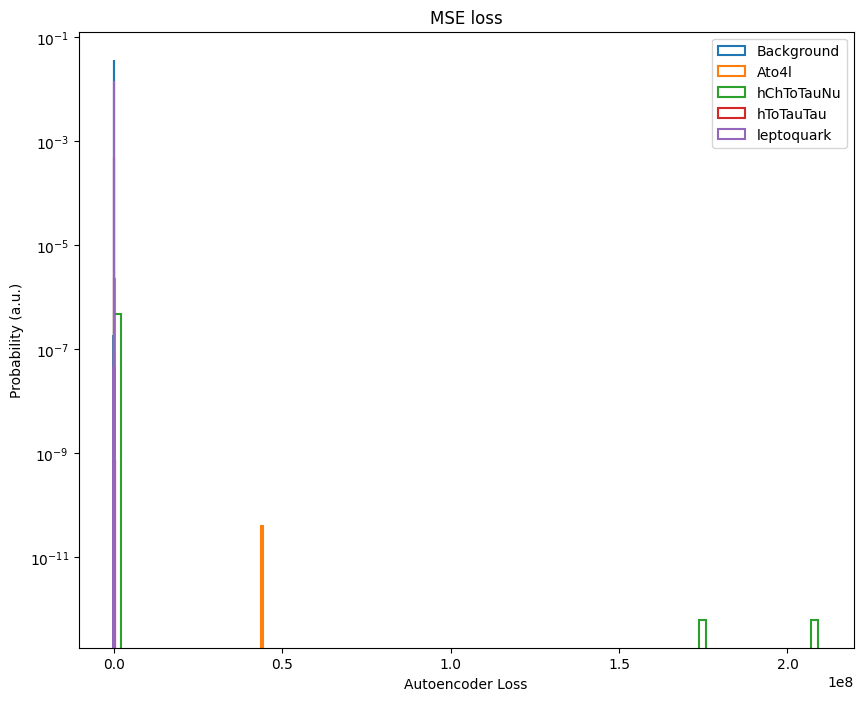

In [ ]:
bin_size=100
labels = np.concatenate([['Background'], np.array(signal_labels)])
plt.figure(figsize=(10,8))
for i, label in enumerate(labels):
    plt.hist(total_loss[i], bins=bin_size, label=label, density = True, histtype='step', fill=False, linewidth=1.5)

plt.yscale('log')
plt.xlabel("Autoencoder Loss")
plt.ylabel("Probability (a.u.)")
plt.title('MSE loss')
plt.legend(loc='best')
plt.show()

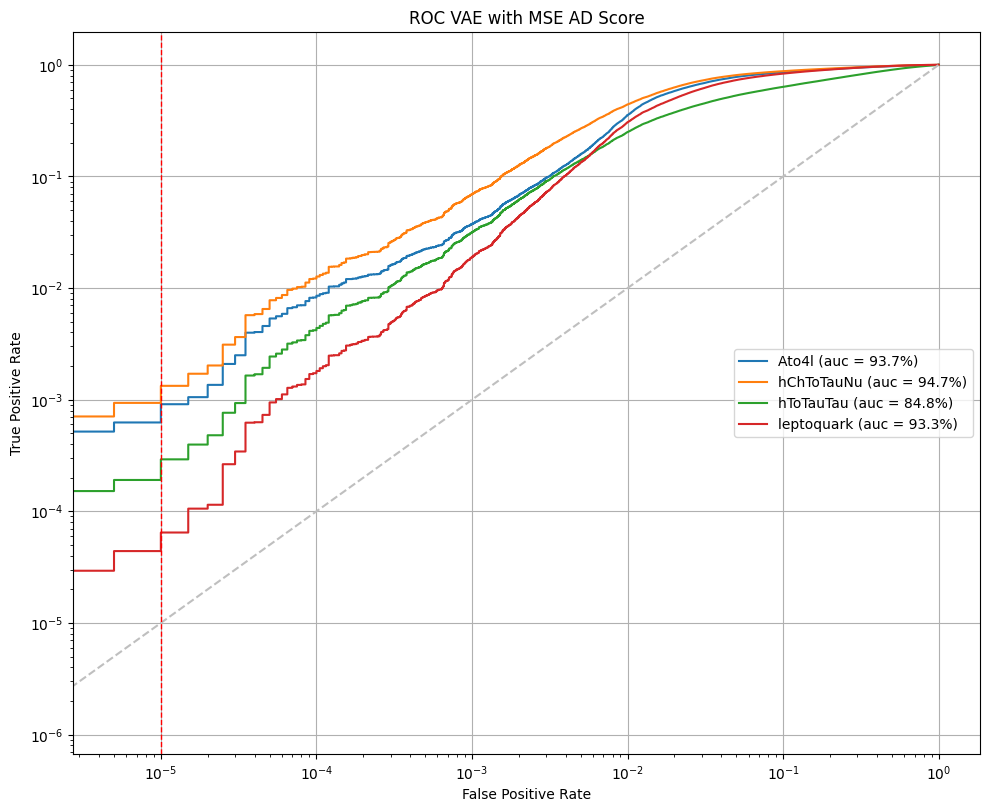

In [ ]:
target_background = np.zeros(total_loss[0].shape[0])

plt.figure(figsize=(10,8))
for i, label in enumerate(labels):
    if i == 0: continue # background events

    trueVal = np.concatenate((np.ones(total_loss[i].shape[0]), target_background)) # anomaly=1, bkg=0
    predVal_loss = np.concatenate((total_loss[i], total_loss[0]))

    fpr_loss, tpr_loss, threshold_loss = roc_curve(trueVal, predVal_loss)

    auc_loss = auc(fpr_loss, tpr_loss)

    plt.plot(fpr_loss, tpr_loss, "-", label='%s (auc = %.1f%%)'%(label,auc_loss*100.), linewidth=1.5)

    plt.semilogx()
    plt.semilogy()
    plt.ylabel("True Positive Rate")
    plt.xlabel("False Positive Rate")
    plt.legend(loc='center right')
    plt.grid(True)
    plt.tight_layout()
plt.plot(np.linspace(0, 1),np.linspace(0, 1), '--', color='0.75')
plt.axvline(0.00001, color='red', linestyle='dashed', linewidth=1) # threshold value for measuring anomaly detection efficiency
plt.title("ROC VAE with MSE AD Score")
plt.show()

In [ ]:
datasets = {label: {} for label in labels}
datasets['train'] = {}
datasets['val'] = {}

datasets['Background']['data'] = X_test
datasets['train']['data'] = X_train
datasets['train']['MSE_AD_scores'] = train_loss
datasets['val']['data'] = X_val
datasets['val']['MSE_AD_scores'] = val_loss

for i, (tag, data_dict) in enumerate(datasets.items()):
    if tag == 'val' or tag == 'train': continue
    data_dict['MSE_AD_scores'] = total_loss[i]

    if i != 0:
        data_dict['data'] = signal_data[i-1]

In [ ]:
for tag, data_dict in datasets.items():
    print(f'{tag}:')
    for key, value in data_dict.items():
        print(f'  {key}: {value.shape}')

Background:
  data: (200000, 57)
  MSE_AD_scores: (200000,)
Ato4l:
  MSE_AD_scores: (55969,)
  data: (55969, 57)
hChToTauNu:
  MSE_AD_scores: (760272,)
  data: (760272, 57)
hToTauTau:
  MSE_AD_scores: (691283,)
  data: (691283, 57)
leptoquark:
  MSE_AD_scores: (340544,)
  data: (340544, 57)
train:
  data: (640000, 57)
  MSE_AD_scores: (640000,)
val:
  data: (160000, 57)
  MSE_AD_scores: (160000,)


## KL AD Score

In [ ]:
# Define AD score
def AD_score(mu, logvar):
    return -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp(), dim=1)

In [ ]:
def clipped_KL_AD_score(mu, logvar):
    return torch.mean(mu.pow(2), dim=1)

In [ ]:
# compute loss value (true, predicted)
train_loss = AD_score(train_mu, train_logvar).detach()
train_clipped_loss = clipped_KL_AD_score(train_mu, train_logvar).detach()
val_loss = AD_score(val_mu, val_logvar).detach()
val_clipped_loss = clipped_KL_AD_score(val_mu, val_logvar).detach()

total_loss = []
clipped_total_loss = []

total_loss.append(AD_score(bkg_mu, bkg_logvar).detach())
clipped_total_loss.append(clipped_KL_AD_score(bkg_mu, bkg_logvar).detach())
for i, signal_X in enumerate(signal_data):
    total_loss.append(AD_score(sig_mu[i], sig_logvar[i]).detach())
    clipped_total_loss.append(clipped_KL_AD_score(sig_mu[i], sig_logvar[i]).detach())

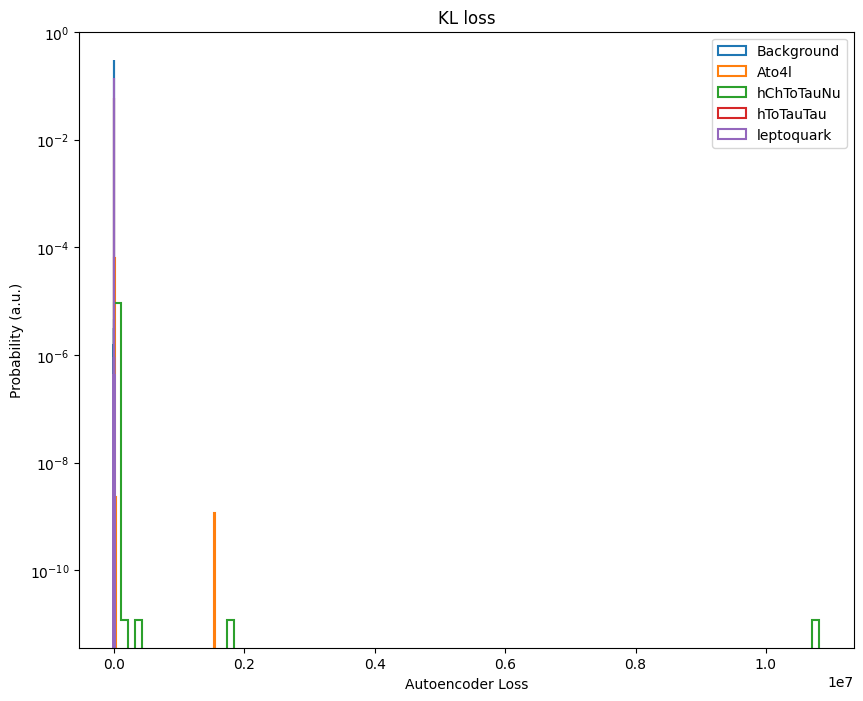

In [ ]:
bin_size=100
labels = np.concatenate([['Background'], np.array(signal_labels)])
plt.figure(figsize=(10,8))
for i, label in enumerate(labels):
    plt.hist(total_loss[i], bins=bin_size, label=label, density = True, histtype='step', fill=False, linewidth=1.5)

plt.yscale('log')
plt.xlabel("Autoencoder Loss")
plt.ylabel("Probability (a.u.)")
plt.title('KL loss')
plt.legend(loc='best')
plt.show()

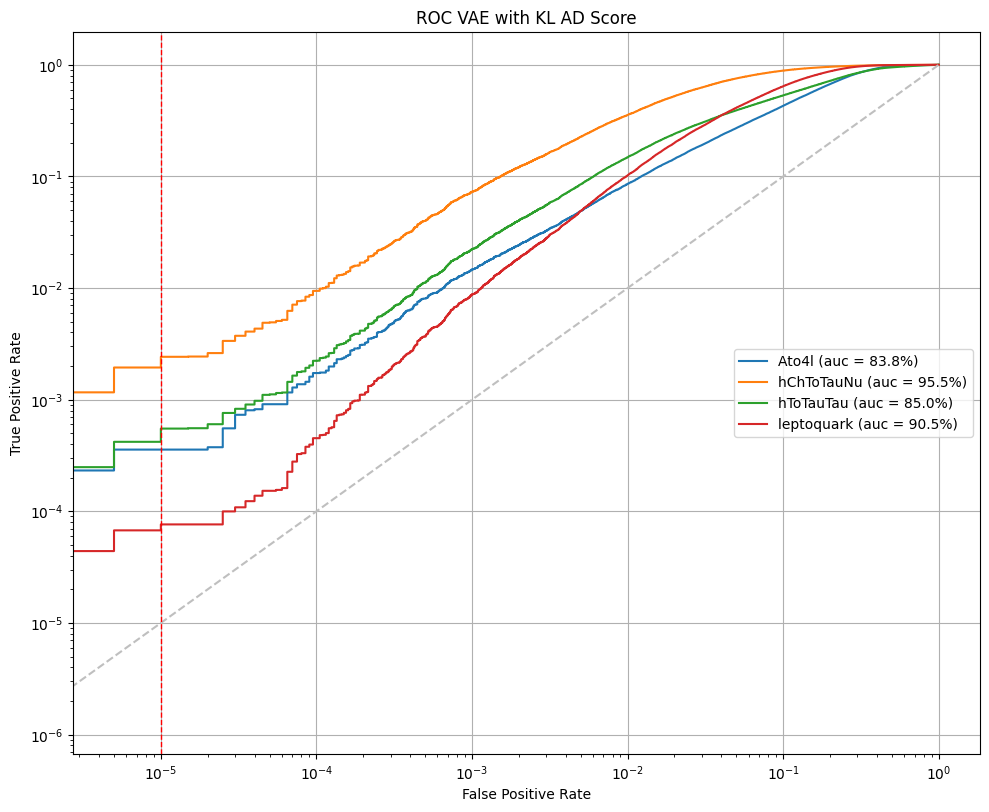

In [ ]:
target_background = np.zeros(total_loss[0].shape[0])

plt.figure(figsize=(10,8))
for i, label in enumerate(labels):
    if i == 0: continue # background events

    trueVal = np.concatenate((np.ones(total_loss[i].shape[0]), target_background)) # anomaly=1, bkg=0
    predVal_loss = np.concatenate((total_loss[i], total_loss[0]))

    fpr_loss, tpr_loss, threshold_loss = roc_curve(trueVal, predVal_loss)

    auc_loss = auc(fpr_loss, tpr_loss)

    plt.plot(fpr_loss, tpr_loss, "-", label='%s (auc = %.1f%%)'%(label,auc_loss*100.), linewidth=1.5)

    plt.semilogx()
    plt.semilogy()
    plt.ylabel("True Positive Rate")
    plt.xlabel("False Positive Rate")
    plt.legend(loc='center right')
    plt.grid(True)
    plt.tight_layout()
plt.plot(np.linspace(0, 1),np.linspace(0, 1), '--', color='0.75')
plt.axvline(0.00001, color='red', linestyle='dashed', linewidth=1) # threshold value for measuring anomaly detection efficiency
plt.title("ROC VAE with KL AD Score")
plt.show()

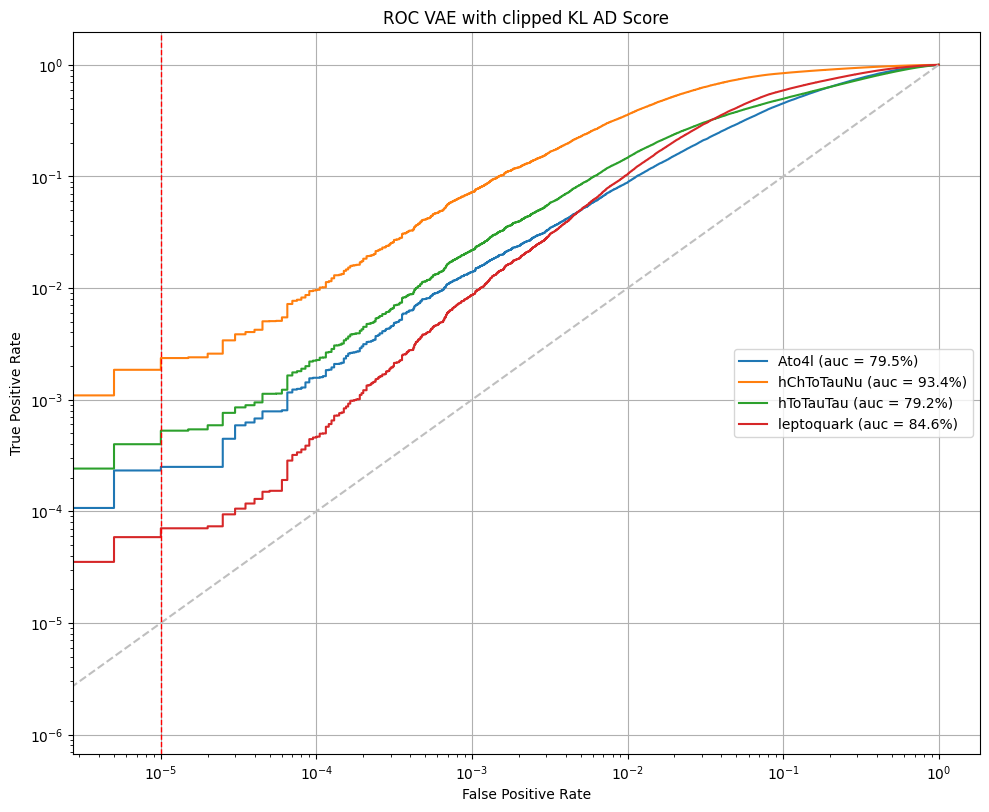

In [ ]:
target_background = np.zeros(clipped_total_loss[0].shape[0])

plt.figure(figsize=(10,8))
for i, label in enumerate(labels):
    if i == 0: continue # background events

    trueVal = np.concatenate((np.ones(clipped_total_loss[i].shape[0]), target_background)) # anomaly=1, bkg=0
    predVal_loss = np.concatenate((clipped_total_loss[i], clipped_total_loss[0]))

    fpr_loss, tpr_loss, threshold_loss = roc_curve(trueVal, predVal_loss)

    auc_loss = auc(fpr_loss, tpr_loss)

    plt.plot(fpr_loss, tpr_loss, "-", label='%s (auc = %.1f%%)'%(label,auc_loss*100.), linewidth=1.5)

    plt.semilogx()
    plt.semilogy()
    plt.ylabel("True Positive Rate")
    plt.xlabel("False Positive Rate")
    plt.legend(loc='center right')
    plt.grid(True)
    plt.tight_layout()
plt.plot(np.linspace(0, 1),np.linspace(0, 1), '--', color='0.75')
plt.axvline(0.00001, color='red', linestyle='dashed', linewidth=1) # threshold value for measuring anomaly detection efficiency
plt.title("ROC VAE with clipped KL AD Score")
plt.show()

In [ ]:
datasets['train']['KL_AD_scores'] = train_loss
datasets['train']['clipped_KL_AD_scores'] = train_clipped_loss
datasets['val']['KL_AD_scores'] = val_loss
datasets['val']['clipped_KL_AD_scores'] = val_clipped_loss

for i, (tag, data_dict) in enumerate(datasets.items()):
    if tag == 'val' or tag == 'train': continue
    data_dict['KL_AD_scores'] = total_loss[i].detach().cpu().numpy()
    data_dict['clipped_KL_AD_scores'] = clipped_total_loss[i].detach().cpu().numpy()

In [ ]:
for tag, data_dict in datasets.items():
    print(f'{tag}:')
    for key, value in data_dict.items():
        print(f'  {key}: {value.shape}')

Background:
  data: (200000, 57)
  MSE_AD_scores: (200000,)
  KL_AD_scores: (200000,)
  clipped_KL_AD_scores: (200000,)
Ato4l:
  MSE_AD_scores: (55969,)
  data: (55969, 57)
  KL_AD_scores: (55969,)
  clipped_KL_AD_scores: (55969,)
hChToTauNu:
  MSE_AD_scores: (760272,)
  data: (760272, 57)
  KL_AD_scores: (760272,)
  clipped_KL_AD_scores: (760272,)
hToTauTau:
  MSE_AD_scores: (691283,)
  data: (691283, 57)
  KL_AD_scores: (691283,)
  clipped_KL_AD_scores: (691283,)
leptoquark:
  MSE_AD_scores: (340544,)
  data: (340544, 57)
  KL_AD_scores: (340544,)
  clipped_KL_AD_scores: (340544,)
train:
  data: (640000, 57)
  MSE_AD_scores: (640000,)
  KL_AD_scores: torch.Size([640000])
  clipped_KL_AD_scores: torch.Size([640000])
val:
  data: (160000, 57)
  MSE_AD_scores: (160000,)
  KL_AD_scores: torch.Size([160000])
  clipped_KL_AD_scores: torch.Size([160000])


In [ ]:
import os
def save_subdicts_to_h5(main_dict, save_dir):
    """
    Saves each sub-dictionary of NumPy arrays in the main_dict to separate HDF5 files.

    Args:
        main_dict (dict): A dictionary of dictionaries where the innermost values are NumPy arrays.
        save_dir (str): The directory where the HDF5 files will be saved.
    """
    # Ensure the save directory exists
    os.makedirs(save_dir, exist_ok=True)

    for sub_dict_name, sub_dict in main_dict.items():
        file_path = os.path.join(save_dir, f"{sub_dict_name}.h5")
        with h5py.File(file_path, 'w') as f:
            for key, arr in sub_dict.items():
                f.create_dataset(key, data=arr)
        print(f"Saved {sub_dict_name} to {file_path}")

save_subdicts_to_h5(datasets, './datasets')

Saved Background to ./datasets/Background.h5
Saved Ato4l to ./datasets/Ato4l.h5
Saved hChToTauNu to ./datasets/hChToTauNu.h5
Saved hToTauTau to ./datasets/hToTauTau.h5
Saved leptoquark to ./datasets/leptoquark.h5
Saved train to ./datasets/train.h5
Saved val to ./datasets/val.h5
